In [1]:
suppressPackageStartupMessages({
  library(future)
  library(Seurat)
  library(tidyverse)
  library(Seurat)
  library(ggplot2)
  library(ggrastr)   # for geom_point_rast()
  library(ggrepel)   # for geom_text_repel()
  library(dplyr)
  library(forcats)
  library(pals)      # for glasbey palette (distinct, color-blind-friendly)
  library(stringr)  
  library(RColorBrewer) # For generating high-quality color palettes
  library(cowplot)      # For the 'theme_cowplot' (a clean, minimal theme)
  library(clusterProfiler)
  library(org.Hs.eg.db)
  library(enrichplot)
  library(ComplexHeatmap)
  library(circlize)
  library(scales)
})

Warning message:
“package ‘Seurat’ was built under R version 4.4.3”
Warning message:
“package ‘SeuratObject’ was built under R version 4.4.3”
Warning message:
“package ‘sp’ was built under R version 4.4.3”


Warning message:
“package ‘tidyverse’ was built under R version 4.4.3”
Warning message:
“package ‘tibble’ was built under R version 4.4.3”
Warning message:
“package ‘readr’ was built under R version 4.4.3”
Warning message:
“package ‘dplyr’ was built under R version 4.4.3”
Warning message:
“package ‘forcats’ was built under R version 4.4.3”
Warning message:
“package ‘lubridate’ was built under R version 4.4.3”
Warning message:
“package ‘ggrastr’ was built under R version 4.4.3”
Warning message:
“package ‘ggrepel’ was built under R version 4.4.3”
Warning message:
“package ‘pals’ was built under R version 4.4.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.4.3”
Warning message:
“package ‘cowplot’ was built under R version 4.4.3”
Warning message:
“package ‘scales’ was built under R version 4.4.3”


In [2]:
# Load annotated myeloid_clean object
myeloid_clean <- readRDS('/mnt/18T/chibao/gliomas/data/upstream/scRNA/official/integrated_v5_optimized/adult/subclusters/myeloid/annotated/myeloid_clean_annotated_v2.rds')
myeloid_clean
myeloid_clean$general_cell_type |> unique()
myeloid_clean@meta.data |> head(2)

An object of class Seurat 
69212 features across 94270 samples within 2 assays 
Active assay: SCT (30606 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, harmony, umap.harmony

[1] "C1Q_MHCII_TAM"    "Homeostatic_TAM"  "Metabolic_TAM"    "SPP1_TAM"        
[5] "Monocyte"         "Inflammatory_TAM" "IFN_TAM"          "Neutrophil"      
[9] "Migration_TAM"

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,SCT_snn_res.0.2,SCT_snn_res.0.4,SCT_snn_res.0.5,SCT_snn_res.0.6,SCT_snn_res.0.7,SCT_snn_res.0.8,SCT_snn_res.1,SCT_snn_res.1.2,seurat_clusters,general_cell_type
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<fct>,<chr>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AACCATGCATATACCG-1,PRJNA1125010,1175,713,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,10.978723,singlet,⋯,0,0,0,0,0,0,0,0,0,C1Q_MHCII_TAM
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AATTTCCCAGTATTCG-1,PRJNA1125010,4284,2090,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,1.960784,singlet,⋯,4,6,6,6,6,7,3,4,4,Homeostatic_TAM


In [3]:
Idents(myeloid_clean) <- "SCT_snn_res.0.08"

In [4]:
# Find markers for each myeloid cell type
myeloid_markers_cluster <- FindAllMarkers(                                                                                                                                      
  object = myeloid_clean,                                                                                                                                             
  assay = "SCT",                                                                                                                                                      
  only.pos = TRUE,                                                                                                                                                    
  min.pct = 0.25,                                                                                                                                                     
  logfc.threshold = 0.25,                                                                                                                                             
  test.use = "wilcox"                                                                                                                                                 
)

Calculating cluster 0



Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 11



In [5]:
cluster0 <- myeloid_markers_cluster %>% filter(cluster == 0) %>% arrange(desc(avg_log2FC))
cluster1 <- myeloid_markers_cluster %>% filter(cluster == 1) %>% arrange(desc(avg_log2FC))
cluster2 <- myeloid_markers_cluster %>% filter(cluster == 2) %>% arrange(desc(avg_log2FC))
cluster3 <- myeloid_markers_cluster %>% filter(cluster == 3) %>% arrange(desc(avg_log2FC))
cluster4 <- myeloid_markers_cluster %>% filter(cluster == 4) %>% arrange(desc(avg_log2FC))
cluster5 <- myeloid_markers_cluster %>% filter(cluster == 5) %>% arrange(desc(avg_log2FC))
cluster6 <- myeloid_markers_cluster %>% filter(cluster == 6) %>% arrange(desc(avg_log2FC))
cluster7 <- myeloid_markers_cluster %>% filter(cluster == 7) %>% arrange(desc(avg_log2FC))
cluster8 <- myeloid_markers_cluster %>% filter(cluster == 8) %>% arrange(desc(avg_log2FC))
cluster9 <- myeloid_markers_cluster %>% filter(cluster == 9) %>% arrange(desc(avg_log2FC))
cluster10 <- myeloid_markers_cluster %>% filter(cluster == 10) %>% arrange(desc(avg_log2FC))
cluster11 <- myeloid_markers_cluster %>% filter(cluster == 11) %>% arrange(desc(avg_log2FC))

In [6]:
cluster6 |> head(20)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
CCL2,0.000000e+00,3.807587,0.445,0.090,0.000000e+00,6,CCL2
SPP11,0.000000e+00,3.252448,0.923,0.404,0.000000e+00,6,SPP1
FCGBP,0.000000e+00,2.559829,0.506,0.141,0.000000e+00,6,FCGBP
APOC21,0.000000e+00,1.978915,0.571,0.213,0.000000e+00,6,APOC2
HAMP,0.000000e+00,1.958881,0.283,0.083,0.000000e+00,6,HAMP
SCIN,0.000000e+00,1.921873,0.328,0.095,0.000000e+00,6,SCIN
PLTP,0.000000e+00,1.820567,0.339,0.101,0.000000e+00,6,PLTP
CTSL1,0.000000e+00,1.780893,0.491,0.176,0.000000e+00,6,CTSL
HTRA1,0.000000e+00,1.589067,0.376,0.143,0.000000e+00,6,HTRA1


In [7]:
cluster0_genes <- myeloid_markers_cluster |> filter(cluster == 0 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster1_genes <- myeloid_markers_cluster |> filter(cluster == 1 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster2_genes <- myeloid_markers_cluster |> filter(cluster == 2 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster3_genes <- myeloid_markers_cluster |> filter(cluster == 3 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster4_genes <- myeloid_markers_cluster |> filter(cluster == 4 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster5_genes <- myeloid_markers_cluster |> filter(cluster == 5 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster6_genes <- myeloid_markers_cluster |> filter(cluster == 6 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster7_genes <- myeloid_markers_cluster |> filter(cluster == 7 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster8_genes <- myeloid_markers_cluster |> filter(cluster == 8 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster9_genes <- myeloid_markers_cluster |> filter(cluster == 9 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster10_genes <- myeloid_markers_cluster |> filter(cluster == 10 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)
cluster11_genes <- myeloid_markers_cluster |> filter(cluster == 11 & p_val_adj < 0.05 & avg_log2FC > 1) |> pull(gene)

In [34]:
# Convert gene symbols to Entrez IDs
entrez_ids <- bitr(
    cluster6_genes,
    fromType = "SYMBOL", 
    toType = "ENTREZID", 
    OrgDb = org.Hs.eg.db)

'select()' returned 1:1 mapping between keys and columns



In [35]:
# GO enrichment analysis
go_result <- enrichGO(gene = entrez_ids$ENTREZID,
                                         OrgDb = org.Hs.eg.db,
                                         ont = "BP",  # Biological Process
                                         pAdjustMethod = "BH",
                                         pvalueCutoff = 0.05,
                                         qvalueCutoff = 0.05
                                         )

Scale for size is already present.
Adding another scale for size, which will replace the existing scale.


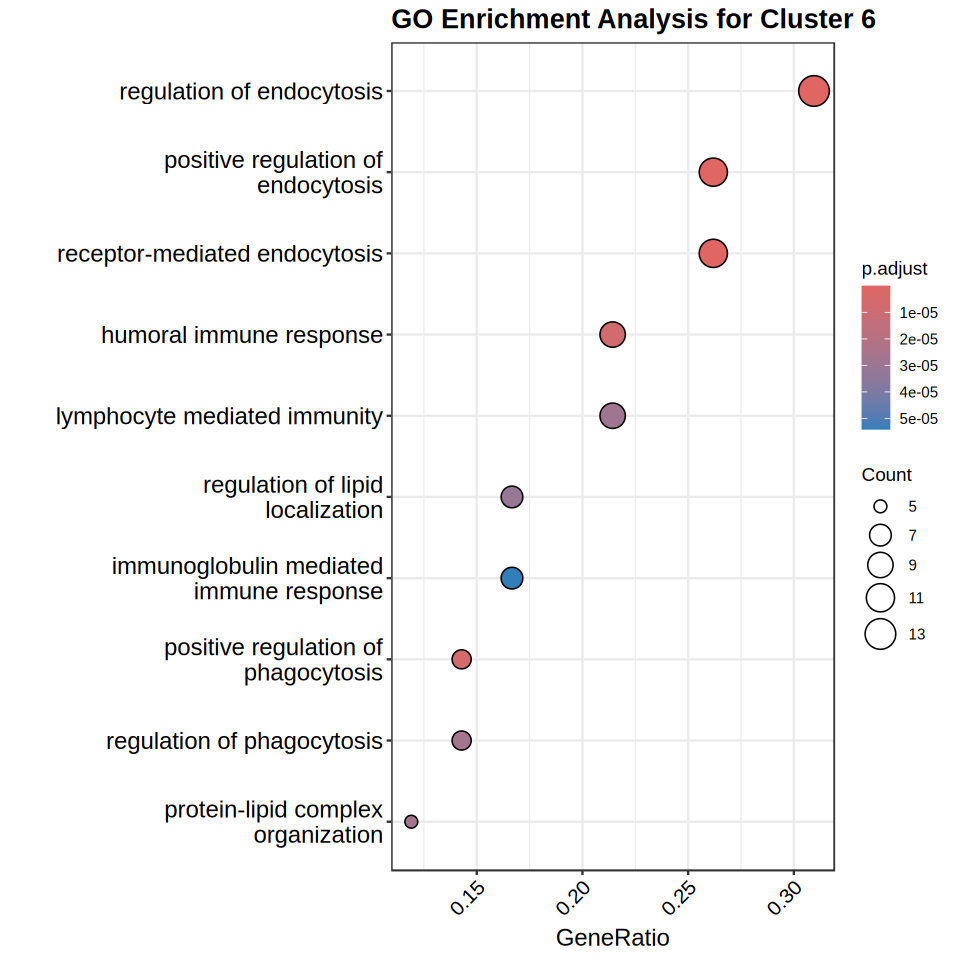

In [36]:
# Visualize GO results
options(repr.plot.width = 8, repr.plot.height = 8)
dotplot(go_result, showCategory = 10) + 
    ggtitle("GO Enrichment Analysis for Cluster 6") +
    theme(plot.title = element_text(size = 16, face = "bold"),
          axis.text.y = element_text(size = 14),
          axis.text.x = element_text(size = 12, angle = 45, hjust = 1),
          axis.title = element_text(size = 14)) +
    scale_size(range = c(3, 8))

In [8]:
Idents(myeloid_clean) <- myeloid_clean$general_cell_type

In [9]:
# Find markers for each myeloid cell type
myeloid_markers <- FindAllMarkers(                                                                                                                                      
  object = myeloid_clean,                                                                                                                                             
  assay = "SCT",                                                                                                                                                      
  only.pos = TRUE,                                                                                                                                                    
  min.pct = 0.25,                                                                                                                                                     
  logfc.threshold = 0.25,                                                                                                                                             
  test.use = "wilcox"                                                                                                                                                 
)

Calculating cluster C1Q_MHCII_TAM

Calculating cluster Homeostatic_TAM

Calculating cluster Metabolic_TAM

Calculating cluster SPP1_TAM

Calculating cluster Monocyte

Calculating cluster Inflammatory_TAM

Calculating cluster IFN_TAM

Calculating cluster Neutrophil

Calculating cluster Migration_TAM



In [10]:
C1Q_TAM <- myeloid_markers %>% filter(cluster == 'C1Q_MHCII_TAM') %>% arrange(desc(avg_log2FC))
MERT_TAM <- myeloid_markers %>% filter(cluster == 'Homeostatic_TAM') %>% arrange(desc(avg_log2FC))
Metabolic_TAM <- myeloid_markers %>% filter(cluster == 'Metabolic_TAM') %>% arrange(desc(avg_log2FC))
SPP1_TAM <- myeloid_markers %>% filter(cluster == 'SPP1_TAM') %>% arrange(desc(avg_log2FC))
Monocyte <- myeloid_markers %>% filter(cluster == 'Monocyte') %>% arrange(desc(avg_log2FC))
Inflammatory_TAM <- myeloid_markers %>% filter(cluster == 'Inflammatory_TAM') %>% arrange(desc(avg_log2FC))
IFN_TAM <- myeloid_markers %>% filter(cluster == 'IFN_TAM') %>% arrange(desc(avg_log2FC))
Neutrophil <- myeloid_markers %>% filter(cluster == 'Neutrophil') %>% arrange(desc(avg_log2FC))
Migration_TAM <- myeloid_markers %>% filter(cluster == 'Migration_TAM') %>% arrange(desc(avg_log2FC))

In [11]:
# Load cNMF object
obj <- readRDS("/mnt/18T/chibao/gliomas/data/upstream/scRNA/official/integrated_v5_optimized/adult/cNMF_myeloid_clean_v2/harmony_annotated_myeloid_clean_cNMF.rds")
obj
obj@meta.data |> head(2)

An object of class Seurat 
69212 features across 94270 samples within 2 assays 
Active assay: SCT (30606 features, 3000 variable features)
 3 layers present: counts, data, scale.data
 1 other assay present: RNA
 3 dimensional reductions calculated: pca, harmony, umap.harmony

,orig.ident,nCount_RNA,nFeature_RNA,project_id,orig_sample_id,sample_uid,genome,chemistry,percent.mt,doublet_class,⋯,seurat_clusters,general_cell_type,cNMF_X1,cNMF_X2,cNMF_X3,cNMF_X4,cNMF_X5,cNMF_X6,cNMF_X7,cNMF_X8
,<chr>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<fct>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AACCATGCATATACCG-1,PRJNA1125010,1175,713,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,10.978723,singlet,⋯,0,Myeloid,0.01881126,0.2174517,0.07846704,0.0000000,0.3990843,0.001591436,0.02268606,0.26190823
PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099_AATTTCCCAGTATTCG-1,PRJNA1125010,4284,2090,PRJNA1125010,PRJNA1125010__filtered_feature_bc_matrix,PRJNA1125010__PRJNA1125010__filtered_feature_bc_matrix__SAMN41882099,GRCh38,10x,1.960784,singlet,⋯,4,Myeloid,0.04776471,0.0000000,0.08146494,0.4118428,0.2408409,0.000000000,0.16578963,0.05229702


Warning message:
“package ‘png’ was built under R version 4.4.3”


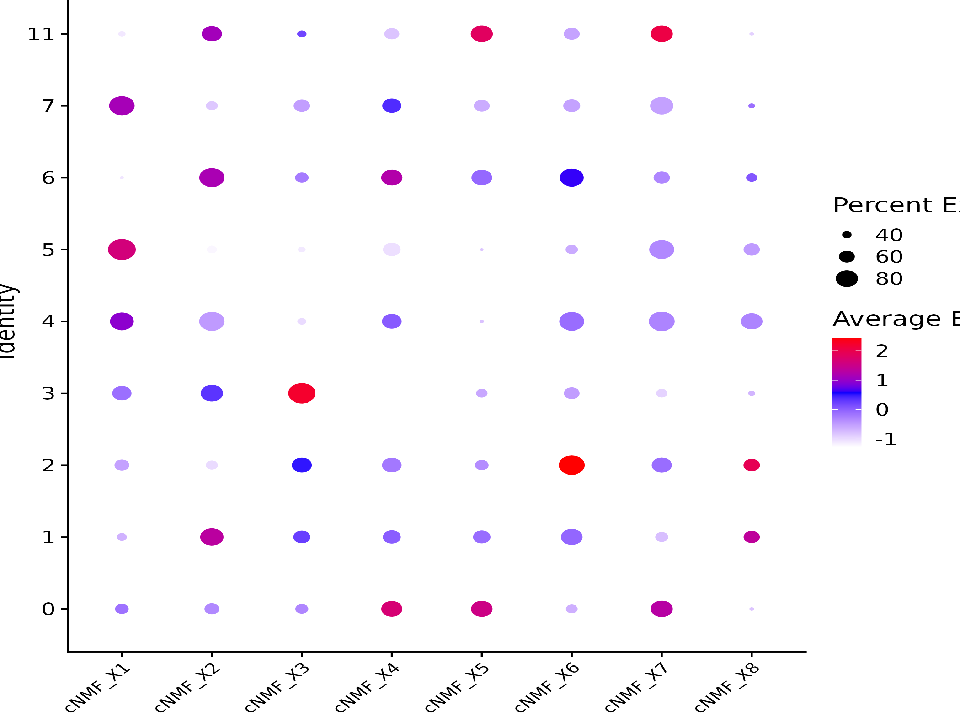

In [12]:
# Load image cNMF heatmap 
library(png)
img <- readPNG('/mnt/18T/chibao/gliomas/data/upstream/scRNA/official/integrated_v5_optimized/adult/cNMF_myeloid_clean_v2/plot.png')
options(repr.plot.width=8, repr.plot.height=6)
# Convert to ggplot object
ggplot() +
    annotation_raster(img, xmin = -Inf, xmax = Inf, ymin = -Inf, ymax = Inf) +
    theme_void()

In [ ]:
# Program 1: Inflammatory => Cluster 4 - 5 - 7 
# Program 2: Antigen Presentation => Cluster 1 - 6 
# Program 3: Interferon => Cluster 3
# Program 4: X => Cluster 0 - 6 
# Program 5: Homeostatic => Cluster 0 - 11 (0 better?)
# Program 6: Metabolic => Cluster 2
# Program 7: Heatshock => Cluster 0 - 11 (11 better?)
# Program 8: Contaminate 

In [13]:
# 2. Define the Dictionary (Map Program Numbers to Cell Types)
# Based on your gene lists analysis:
program_mapping <- list(
  "Inflammatory" = c(1),          
  "Antigen Presentation" = c(2), 
  "Interferon" = c(3),         
  "Chemotaxis" = c(4),        
  "Homeostatic" = c(5),       
  "Metabolic" = c(6),              
  "Heatshock" = c(7),            
  'Contaminate' = c(8) # Ignored
)

In [14]:
# 3. Assign Identity
# We find the max program for each cell and map it to a name.
cnmf_usage_cols <- paste0("cNMF_X", 1:8)
usage_matrix <- obj@meta.data[, cnmf_usage_cols]

# Find column index of max value
max_col_idx <- max.col(usage_matrix, ties.method = "first")
obj$Max_Program_Num <- max_col_idx

# Function to lookup name
get_identity <- function(prog_num) {
  for (type in names(program_mapping)) {
    if (prog_num %in% program_mapping[[type]]) return(type)
  }
  return("Unknown")
}

obj$cNMF_Broad_Identity <- sapply(obj$Max_Program_Num, get_identity)

# 4. Verify the split
table(obj$cNMF_Broad_Identity)


Antigen Presentation           Chemotaxis          Contaminate 
               25297                11501                 1138 
           Heatshock          Homeostatic         Inflammatory 
                3332                 6227                28211 
          Interferon            Metabolic 
               12469                 6095 

In [15]:
# ==============================================================================
# FILTERING STEP
# ==============================================================================
# Now that 'cNMF_Broad_Identity' exists, we can use it to filter.

# A. List the exact names you gave to Program 11 and 12 in your dictionary
garbage_identities <- c('Contaminate') 

# B. Identify the cells
cells_to_remove <- rownames(obj@meta.data[obj$cNMF_Broad_Identity %in% garbage_identities, ])

# C. Remove them
# We overwrite 'obj' with the clean version (or create 'obj_clean' if you prefer safety)
obj <- subset(obj, cells = cells_to_remove, invert = TRUE)

message("Removed ", length(cells_to_remove), " cells belonging to: ", paste(garbage_identities, collapse=", "))

# ==============================================================================
# Verify the split (EXISTING CODE)
# ==============================================================================
# Now when you run this, the garbage classes should be gone
table(obj$cNMF_Broad_Identity)

Removed 1138 cells belonging to: Contaminate




Antigen Presentation           Chemotaxis            Heatshock 
               25297                11501                 3332 
         Homeostatic         Inflammatory           Interferon 
                6227                28211                12469 
           Metabolic 
                6095 

In [16]:
# ==============================================================================
# Step A: Load the Spectra Matrix
# ==============================================================================

# Config (Ensure these match your K=14 run)
cnmf_dir <- "/mnt/18T/chibao/gliomas/data/upstream/scRNA/official/integrated_v5_optimized/adult/cNMF_myeloid_clean_v2"
run_name <- "Glioma_Adult_Myeloid"
k_val <- 8 

# Construct path to the Spectra Score file
spectra_file <- file.path(cnmf_dir, run_name, 
                          paste0(run_name, ".gene_spectra_score.k_", k_val, ".dt_0_02.txt"))

# Read and convert to matrix
spectra <- read.table(spectra_file, header = TRUE, row.names = 1, sep = "\t")
spectra <- as.matrix(spectra)

In [17]:
# ==============================================================================
# Step B: View Top Genes
# ==============================================================================

# Function to get top N genes
get_top_genes <- function(prog_num, n=50) {
  names(sort(spectra[prog_num,], decreasing = TRUE))[1:n]
}

# OPTION 1: Print to Console
# This lets you quickly scroll through and spot familiar names
for (i in 1:k_val) {
  cat(paste0("\n=== Program ", i, " ===\n"))
  print(get_top_genes(i, n = 30)) # Prints top 30 genes
}

# OPTION 2: Save to a text file (Recommended)
# This creates a file you can open in Excel/Notepad to copy-paste from
output_file <- "/mnt/18T/chibao/gliomas/data/upstream/scRNA/official/integrated_v5_optimized/adult/cNMF_myeloid_clean_v2/cNMF_Top_Genes_List.txt"
sink(output_file)
for (i in 1:k_val) {
  cat(paste0("Program ", i, "\t", paste(get_top_genes(i, n=100), collapse=", "), "\n"))
}
sink()

message("Gene list saved to: ", output_file)


=== Program 1 ===
 [1] "VCAN"    "ZEB2"    "FCN1"    "LYZ"     "CD300E"  "CD36"    "MAP3K1" 
 [8] "CTSS"    "S100A9"  "PID1"    "DPYD"    "ATP2B1"  "AHNAK"   "USP3"   
[15] "S100A4"  "AOAH"    "PLCB1"   "EMILIN2" "S100A12" "SLCO3A1" "COTL1"  
[22] "CLEC12A" "CD48"    "MPEG1"   "STK17B"  "MT.ND1"  "JARID2"  "GAS7"   
[29] "AGTPBP1" "PTPRC"  

=== Program 2 ===
 [1] "CD74"     "NAPSB"    "TREM2"    "C1QC"     "CD81"     "PLD4"    
 [7] "HLA.DRB5" "APOO"     "HLA.DRB1" "RHOB"     "HLA.DPA1" "RNASET2" 
[13] "MT.ATP8"  "HLA.DRA"  "ZFP36"    "APOE"     "KLF2"     "ACTB"    
[19] "HLA.DQA1" "HLA.DMA"  "C1QB"     "ALOX5AP"  "LILRB4"   "DUSP1"   
[25] "YWHAH"    "C3"       "CEBPD"    "HLA.DPB1" "CAPG"     "CST3"    

=== Program 3 ===
 [1] "CHRM3"  "NRCAM"  "ISG15"  "TENM2"  "IGFBP7" "GRIK2"  "RBP4"   "MX1"   
 [9] "CDKN2A" "CALD1"  "GLIS3"  "IFI27"  "PTN"    "TNIK"   "GPC6"   "NTRK2" 
[17] "SOX5"   "IFI44L" "MDK"    "MSI2"   "GABRG3" "KCNIP4" "PDE4D"  "ADAM12"
[25] "LHFPL6" "SDK1"   "EYA4"   

Gene list saved to: /mnt/18T/chibao/gliomas/data/upstream/scRNA/official/integrated_v5_optimized/adult/cNMF_myeloid_clean_v2/cNMF_Top_Genes_List.txt



In [18]:
# 1. Define the programs you kept (exclude the garbage ones like 11, 12)
# Use the logic from your program_mapping
valid_programs <- c(1, 2, 3, 4, 5, 6, 7) # Example list based on your previous cleanup

# 2. Extract Top 5 Candidates for each Valid Program
# We pull these from the Spectra matrix you loaded earlier
candidates_list <- list()

for (i in valid_programs) {
  # Get top 5 genes by weight
  top_5 <- names(sort(spectra[i,], decreasing = TRUE))[1:10]
  
  # Name them so we know which program they belong to
  prog_name <- names(program_mapping)[sapply(program_mapping, function(x) i %in% x)]
  if(length(prog_name) == 0) prog_name <- paste0("Prog_", i)
  
  candidates_list[[prog_name]] <- top_5
}

# Flatten the list for plotting
all_candidates <- unique(unlist(candidates_list))

In [19]:
print(candidates_list)

$Inflammatory
 [1] "VCAN"   "ZEB2"   "FCN1"   "LYZ"    "CD300E" "CD36"   "MAP3K1" "CTSS"  
 [9] "S100A9" "PID1"  

$`Antigen Presentation`
 [1] "CD74"     "NAPSB"    "TREM2"    "C1QC"     "CD81"     "PLD4"    
 [7] "HLA.DRB5" "APOO"     "HLA.DRB1" "RHOB"    

$Interferon
 [1] "CHRM3"  "NRCAM"  "ISG15"  "TENM2"  "IGFBP7" "GRIK2"  "RBP4"   "MX1"   
 [9] "CDKN2A" "CALD1" 

$Chemotaxis
 [1] "ZNF331"   "ANKH"     "SLC16A10" "NR4A3"    "ATP1B3"   "GPR183"  
 [7] "EPB41L3"  "DOCK4"    "MALT1"    "SIPA1L1" 

$Homeostatic
 [1] "FRMD4A"    "LRMDA"     "SFMBT2"    "PLXDC2"    "MEF2A"     "SYNDIG1"  
 [7] "SLC9A9"    "FAM149A"   "LINC02232" "ARHGAP24" 

$Metabolic
 [1] "ALDOA" "GAPDH" "CSTB"  "GPNMB" "LDHA"  "ENO2"  "BNIP3" "VIM"   "MT1X" 
[10] "MIF"  

$Heatshock
 [1] "ENSG00000290122" "TRA2B"           "ENSG00000288755" "JUN"            
 [5] "ENSG00000253736" "POLG2"           "DNAJA1"          "LRRC23"         
 [9] "PLK2"            "SLC38A2"        



In [20]:
# ==============================================================================
# Modified Step 2: Manual Gene Selection
# ==============================================================================

# 1. Define your Custom List
# Group them by the Program/Identity you want to show.
# You can choose different numbers of genes for each group.
custom_genes_list <- list(
    'Inflammatory' = c('VCAN', 'S100A9', 'LYZ', 'CTSS', 'JAML'),
    'Antigen Presentation' = c('CD74', 'C1QC', 'HLA-DRB5', 'HLA-DRB1', 'HLA-DPA1'),
    'Interferon' = c('ISG15', 'IFI27', 'IFI44L', 'IFIT1', 'IFIT3'),
    'Chemotaxis' = c('NR4A3', 'CREM', 'DOCK4', 'GPR183', 'FMNL2'),
    'Homeostatic' = c('ELMO1', 'ARHGAP24', 'FRMD4A', 'SLC9A9', 'ITPR2'),
    'Metabolic' = c('MT1X', 'MT1E', 'BNIP3', 'HK2', 'MT2A'),
    'Heatshock' = c('JUN', 'FOSB', 'HSPH1', 'HSPD1', 'DNAJA1')
)

In [21]:
# 2. Flatten to a vector
heatmap_genes <- unique(unlist(custom_genes_list))

In [22]:
# 3. CRITICAL: Intersect with your object to remove missing genes
# (Assuming your object is named 'obj_myeloid' or similar)
valid_heatmap_genes <- intersect(heatmap_genes, rownames(obj))

In [23]:
# Warn if any are missing
missing_genes <- setdiff(heatmap_genes, rownames(obj))
if(length(missing_genes) > 0) {
  message("Warning: These genes are missing and will be skipped: ", paste(missing_genes, collapse=", "))
}

In [24]:
# 4. Create the Row Split Vector
# This ensures the heatmap rows are grouped by your Program Names, not mixed up.
# We iterate through your list and keep only the valid genes.
gene_groups <- character()
for (prog_name in names(custom_genes_list)) {
  genes_in_prog <- custom_genes_list[[prog_name]]
  valid_genes_in_prog <- intersect(genes_in_prog, valid_heatmap_genes)
  
  if (length(valid_genes_in_prog) > 0) {
    gene_groups <- c(gene_groups, rep(prog_name, length(valid_genes_in_prog)))
  }
}
# Make it a factor to preserve your specific order (Inflammatory -> Antigen -> ...)
gene_groups <- factor(gene_groups, levels = names(custom_genes_list))

In [25]:
# 1. Scale Data for these specific genes
# We do this to ensure the colors are comparable (Z-scores)
obj <- ScaleData(obj, features = valid_heatmap_genes, assay = "SCT")

Centering and scaling data matrix



In [26]:
# 2. Extract the Matrix
# Ensure we are pulling from the scaled slot
mat <- GetAssayData(obj, assay = "SCT", layer = "scale.data")[valid_heatmap_genes, ]

In [27]:
# 3. Clip Outliers (Standard practice for heatmaps)
# This prevents one extremely high cell from washing out the color scale
mat[mat > 2.5] <- 2.5
mat[mat < -2.5] <- -2.5

In [28]:
# 4. Define Colors for the Annotation Bar (Optional but nice)
# Create a color mapping for your cNMF Identity labels
unique_identities <- unique(obj$cNMF_Broad_Identity)
# Assign random colors or define your own
identity_colors <- structure(scales::hue_pal()(length(unique_identities)), names = unique_identities)

In [29]:
# 2. Transfer the labels to the cNMF object
# We use AddMetaData to ensure barcodes match perfectly
# (Assuming 'general_cell_type' is the column name in your manual object)
manual_labels <- myeloid_clean$general_cell_type
names(manual_labels) <- colnames(myeloid_clean)

obj <- AddMetaData(obj, metadata = manual_labels, col.name = "Manual_Identity")

# 3. Check for NAs (in case some cells were filtered differently)
# If NAs exist, label them "Unknown"
obj$Manual_Identity[is.na(obj$Manual_Identity)] <- "Unknown"

In [30]:
# 1. Define Colors for Manual Annotations
manual_types <- unique(obj$Manual_Identity)
manual_colors <- structure(hue_pal()(length(manual_types)), names = manual_types)

# 2. Define Colors for cNMF Broad Identity (Optional, for comparison)
cnmf_types <- unique(obj$cNMF_Broad_Identity)
cnmf_colors <- structure(grey.colors(length(cnmf_types)), names = cnmf_types)

# 3. Create the Top Annotation
# This puts the colored bars above the heatmap
# top_anno <- HeatmapAnnotation(
#   Manual_Type = obj$Manual_Identity,
#   cNMF_Identity = obj$cNMF_Broad_Identity,
#   col = list(
#     Manual_Type = manual_colors,
#     cNMF_Identity = cnmf_colors
#   ),
#   annotation_legend_param = list(
#     Manual_Type = list(title = "Manual Cell Type"),
#     cNMF_Identity = list(title = "cNMF Program")
#   )
# )
top_anno <- HeatmapAnnotation(
  Manual_Type = obj$Manual_Identity,
  cNMF_Identity = obj$cNMF_Broad_Identity,
  col = list(
    Manual_Type = manual_colors,
    cNMF_Identity = cnmf_colors
  ),
  annotation_legend_param = list(
    Manual_Type = list(
        title = "Manual Cell Type", 
        title_gp = gpar(fontsize = 16, fontface = "bold"), # INCREASE LEGEND TITLE
        labels_gp = gpar(fontsize = 14),                   # INCREASE LEGEND LABELS
        grid_width = unit(8, "mm"),                        # INCREASE COLOR BOX SIZE
        grid_height = unit(8, "mm")
    ),
    cNMF_Identity = list(
        title = "cNMF Program",
        title_gp = gpar(fontsize = 16, fontface = "bold"), # INCREASE LEGEND TITLE
        labels_gp = gpar(fontsize = 14),                   # INCREASE LEGEND LABELS
        grid_width = unit(8, "mm"),
        grid_height = unit(8, "mm")
    )
  )
)

In [31]:
# 1. Calculate a "Sorting Score"
# We find the usage of the program that matches the cell's assigned cNMF identity
# (This makes the "red" blocks look sharpest)
usage_matrix <- obj@meta.data[, paste0("cNMF_X", 1:8)]
obj$Max_Usage_Score <- apply(usage_matrix, 1, max)

# 2. Define the Order
# Order by Manual Type first, then by Program Strength (descending)
cell_order <- order(obj$Manual_Identity, -obj$Max_Usage_Score)

# 3. Re-order the matrix for the heatmap
mat_ordered <- mat[, cell_order]

In [32]:
p_final <- Heatmap(mat_ordered,
        name = "Z-Score",
        
        # --- SPLITS ---
        column_split = obj$Manual_Identity[cell_order], 
        row_split = gene_groups,
        
        cluster_columns = FALSE, 
        cluster_rows = FALSE,
        
        row_title_rot = 0,
        row_gap = unit(4, "mm"),    # Increase gap slightly for bigger text
        column_gap = unit(2, "mm"),
        
        # --- AESTHETICS (MODIFIED) ---
        show_column_names = FALSE,
        top_annotation = top_anno[cell_order],
        
        # 1. INCREASE GENE NAME SIZE (Rows)
        row_names_gp = gpar(fontsize = 30), 
        
        # 2. INCREASE PATHWAY NAME SIZE (Row Splits)
        row_title_gp = gpar(fontsize = 30, fontface = "bold"),
        
        # 3. INCREASE CLUSTER NAME SIZE (Columns)
        column_title_gp = gpar(fontsize = 25, fontface = "bold"),
        column_title_rot = 90,
        
        # 4. INCREASE MAIN LEGEND SIZE (Z-Score Bar)
        heatmap_legend_param = list(
            title = "Expression\n(Z-Score)",
            title_gp = gpar(fontsize = 20, fontface = "bold"),
            labels_gp = gpar(fontsize = 24),
            legend_height = unit(6, "cm"), # Make the color bar longer
            grid_width = unit(8, "mm")     # Make the color bar wider
        ),
        
        col = colorRamp2(c(-2, 0, 2), c("blue", "white", "red"))
)

`use_raster` is automatically set to TRUE for a matrix with more than
2000 columns You can control `use_raster` argument by explicitly
setting TRUE/FALSE to it.

Set `ht_opt$message = FALSE` to turn off this message.



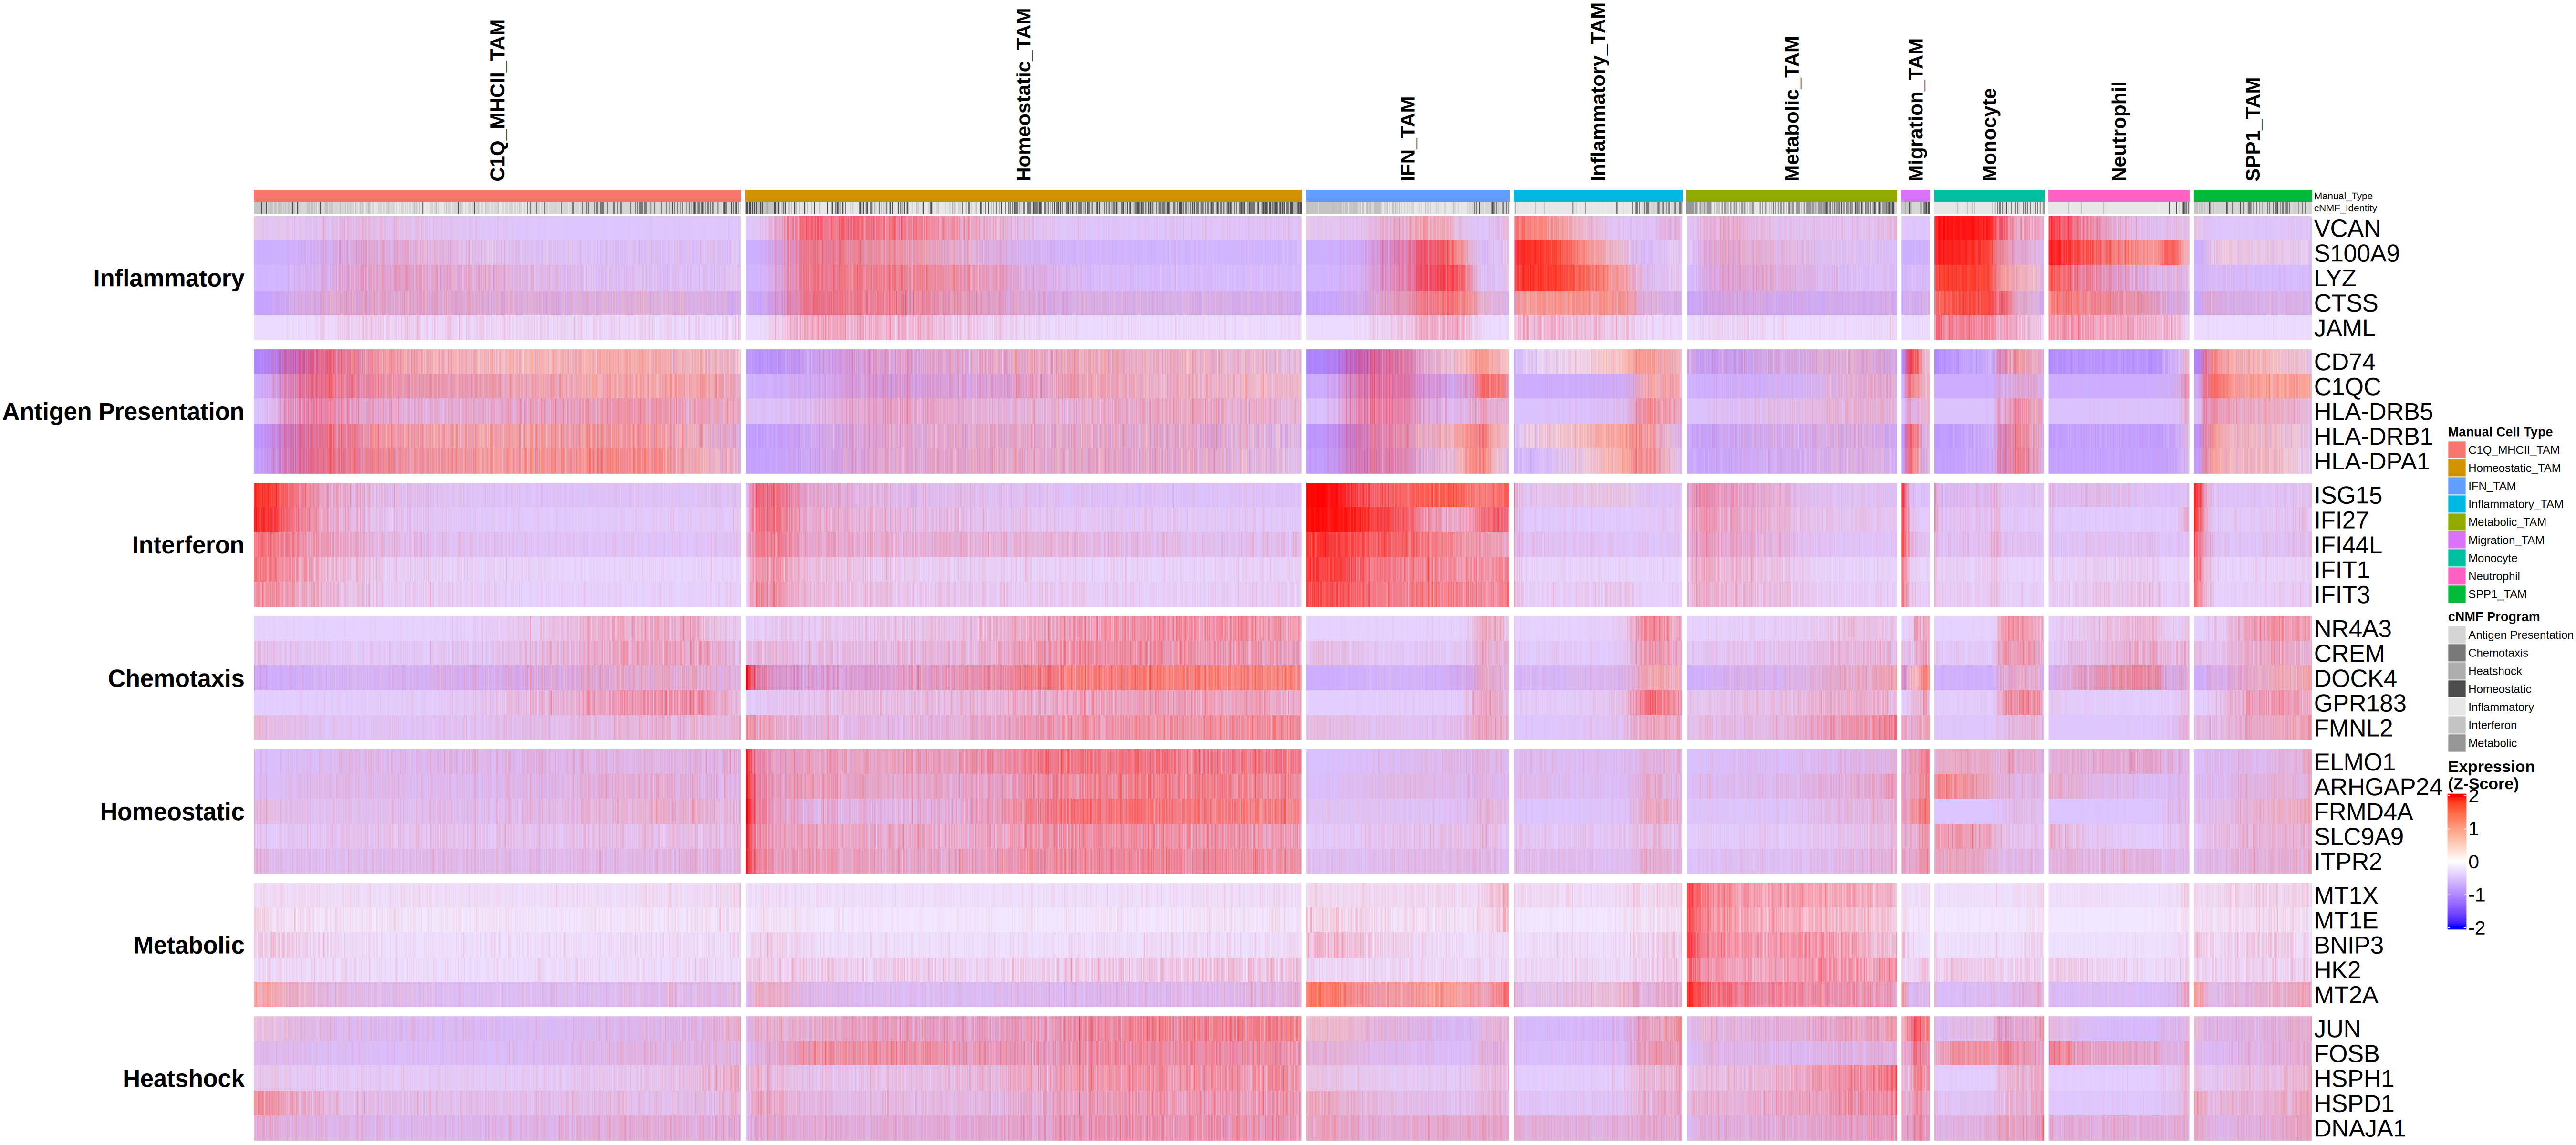

In [33]:
# Draw it
options(repr.plot.width = 45, repr.plot.height = 20)
draw(p_final, merge_legend = TRUE)

In [34]:
myeloid_clean$general_cell_type |> unique()

[1] "C1Q_MHCII_TAM"    "Homeostatic_TAM"  "Metabolic_TAM"    "SPP1_TAM"        
[5] "Monocyte"         "Inflammatory_TAM" "IFN_TAM"          "Neutrophil"      
[9] "Migration_TAM"